In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./demographic.csv")

In [3]:
# Convert date column from object datatype to datetime
print(df.shape)
df["date"] = pd.to_datetime(df["date"],format="%d-%m-%Y")
print(df["date"].dtype)
print(pd.isna(df).sum())

(2071700, 6)
datetime64[ns]
date             0
state            0
district         0
pincode          0
demo_age_5_17    0
demo_age_17_     0
dtype: int64


In [4]:
# Identify correct
print(df["state"].unique())

['Uttar Pradesh' 'Andhra Pradesh' 'Gujarat' 'Rajasthan' 'Karnataka'
 'West Bengal' 'Telangana' 'Odisha' 'Maharashtra' 'Kerala' 'Bihar'
 'Tamil Nadu' 'Madhya Pradesh' 'Assam' 'Tripura' 'Arunachal Pradesh'
 'Punjab' 'Jharkhand' 'Delhi' 'Chandigarh' 'Chhattisgarh'
 'Jammu and Kashmir' 'Mizoram' 'Nagaland' 'Himachal Pradesh' 'Goa'
 'Haryana' 'Meghalaya' 'Uttarakhand' 'Manipur' 'Daman and Diu'
 'Puducherry' 'Sikkim' 'Ladakh' 'Dadra and Nagar Haveli and Daman and Diu'
 'Dadra and Nagar Haveli' 'Orissa' 'Pondicherry'
 'Andaman & Nicobar Islands' 'Andaman and Nicobar Islands' 'west Bengal'
 'Daman & Diu' 'West  Bengal' 'odisha' 'Jammu & Kashmir' 'Lakshadweep'
 'Dadra & Nagar Haveli' 'Westbengal' 'andhra pradesh' 'WEST BENGAL'
 'West Bangal' 'West bengal' 'ODISHA' 'WESTBENGAL' 'Chhatisgarh'
 'West Bengli' 'Darbhanga' 'Puttenahalli' 'Uttaranchal' 'BALANAGAR'
 'Jaipur' 'Madanapalle' '100000' 'Nagpur' 'Raja Annamalai Puram']


In [5]:
# Remove wrong state names
bad_values = [
    "Darbhanga", "Puttenahalli", "Balanagar", "Jaipur",
    "Madanapalle", "Nagpur", "Raja Annamalai Puram", "100000","BALANAGAR"
]

df.drop(df[df['state'].isin(bad_values)].index, inplace=True)
df['state'].unique()

array(['Uttar Pradesh', 'Andhra Pradesh', 'Gujarat', 'Rajasthan',
       'Karnataka', 'West Bengal', 'Telangana', 'Odisha', 'Maharashtra',
       'Kerala', 'Bihar', 'Tamil Nadu', 'Madhya Pradesh', 'Assam',
       'Tripura', 'Arunachal Pradesh', 'Punjab', 'Jharkhand', 'Delhi',
       'Chandigarh', 'Chhattisgarh', 'Jammu and Kashmir', 'Mizoram',
       'Nagaland', 'Himachal Pradesh', 'Goa', 'Haryana', 'Meghalaya',
       'Uttarakhand', 'Manipur', 'Daman and Diu', 'Puducherry', 'Sikkim',
       'Ladakh', 'Dadra and Nagar Haveli and Daman and Diu',
       'Dadra and Nagar Haveli', 'Orissa', 'Pondicherry',
       'Andaman & Nicobar Islands', 'Andaman and Nicobar Islands',
       'west Bengal', 'Daman & Diu', 'West  Bengal', 'odisha',
       'Jammu & Kashmir', 'Lakshadweep', 'Dadra & Nagar Haveli',
       'Westbengal', 'andhra pradesh', 'WEST BENGAL', 'West Bangal',
       'West bengal', 'ODISHA', 'WESTBENGAL', 'Chhatisgarh',
       'West Bengli', 'Uttaranchal'], dtype=object)

In [6]:
# Map to correct state names
state_mapping = {
    # West Bengal variants
    "west Bengal": "West Bengal",
    "West  Bengal": "West Bengal",
    "Westbengal": "West Bengal",
    "WEST BENGAL": "West Bengal",
    "West Bangal": "West Bengal",
    "West bengal": "West Bengal",
    "WESTBENGAL": "West Bengal",
    "West Bengli": "West Bengal",

    # Odisha variants
    "odisha": "Odisha",
    "ODISHA": "Odisha",
    "Orissa": "Odisha",

    # Andhra Pradesh
    "andhra pradesh": "Andhra Pradesh",

    # Jammu & Kashmir
    "Jammu & Kashmir": "Jammu and Kashmir",

    # Chhattisgarh misspelling
    "Chhatisgarh": "Chhattisgarh",

    # Puducherry old name
    "Pondicherry": "Puducherry",

    # Uttarakhand old name
    "Uttaranchal": "Uttarakhand",

    # Daman & Diu
    "Daman & Diu": "Dadra and Nagar Haveli and Daman and Diu",
    "Daman and Diu": "Dadra and Nagar Haveli and Daman and Diu",

    # Dadra & Nagar Haveli
    "Dadra & Nagar Haveli": "Dadra and Nagar Haveli and Daman and Diu",
    "Dadra and Nagar Haveli": "Dadra and Nagar Haveli and Daman and Diu",

    # Andaman & Nicobar Islands
    "Andaman & Nicobar Islands": "Andaman and Nicobar Islands",
}

df['state'] = df['state'].replace(state_mapping)
df['state'].unique()

array(['Uttar Pradesh', 'Andhra Pradesh', 'Gujarat', 'Rajasthan',
       'Karnataka', 'West Bengal', 'Telangana', 'Odisha', 'Maharashtra',
       'Kerala', 'Bihar', 'Tamil Nadu', 'Madhya Pradesh', 'Assam',
       'Tripura', 'Arunachal Pradesh', 'Punjab', 'Jharkhand', 'Delhi',
       'Chandigarh', 'Chhattisgarh', 'Jammu and Kashmir', 'Mizoram',
       'Nagaland', 'Himachal Pradesh', 'Goa', 'Haryana', 'Meghalaya',
       'Uttarakhand', 'Manipur',
       'Dadra and Nagar Haveli and Daman and Diu', 'Puducherry', 'Sikkim',
       'Ladakh', 'Andaman and Nicobar Islands', 'Lakshadweep'],
      dtype=object)

In [7]:
# Find duplicate data
df.duplicated().sum()            

np.int64(474301)

In [8]:
# Remove duplicate data
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [9]:
# Aggregate duplicates by pincode and date
print(df.duplicated(subset=["pincode","date"]).sum())

df = df.groupby(["pincode", "date"], as_index=False).agg({"state": "first","demo_age_5_17": "sum","demo_age_17_": "sum"})

df = df.drop_duplicates()
print(df.duplicated(subset=["pincode","date"]).sum())

299228
0


In [10]:
# Add Total Enrollments column
df["total_enrollment"] = df["demo_age_17_"]+df["demo_age_5_17"]

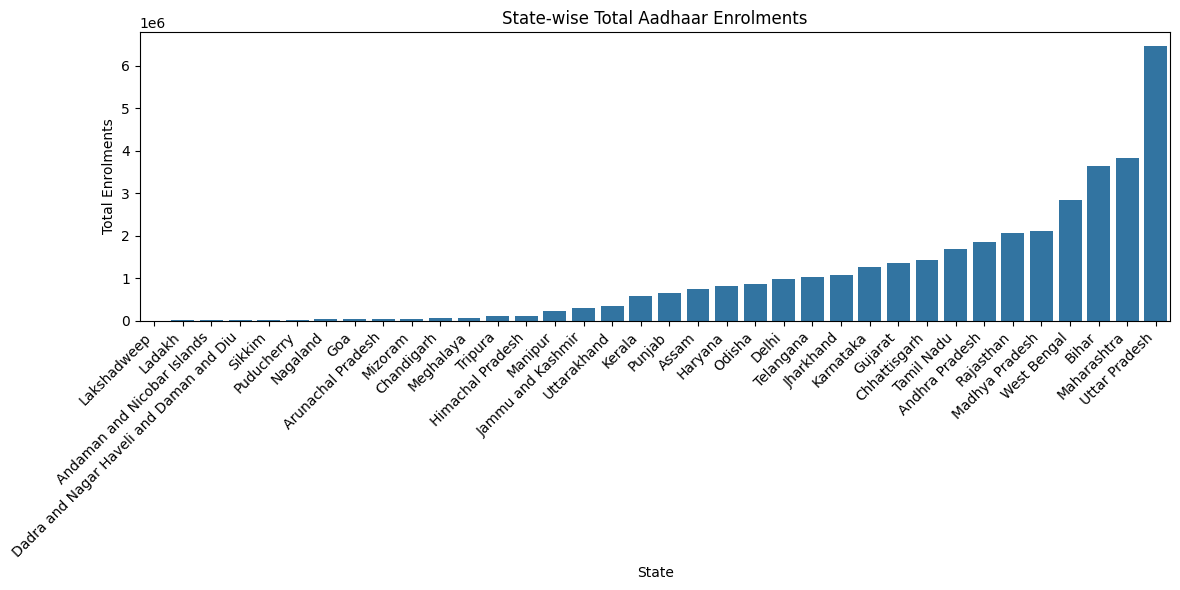

In [11]:
# Visualise state-wise Enrollment
state_df = df.groupby("state", as_index=False)["total_enrollment"].sum().sort_values("total_enrollment")

plt.figure(figsize=(12, 6))
sns.barplot(data=state_df,x="state",y="total_enrollment")

plt.xticks(rotation=45, ha="right")
plt.title("State-wise Total Aadhaar Enrolments")
plt.xlabel("State")
plt.ylabel("Total Enrolments")
plt.tight_layout()
plt.show()

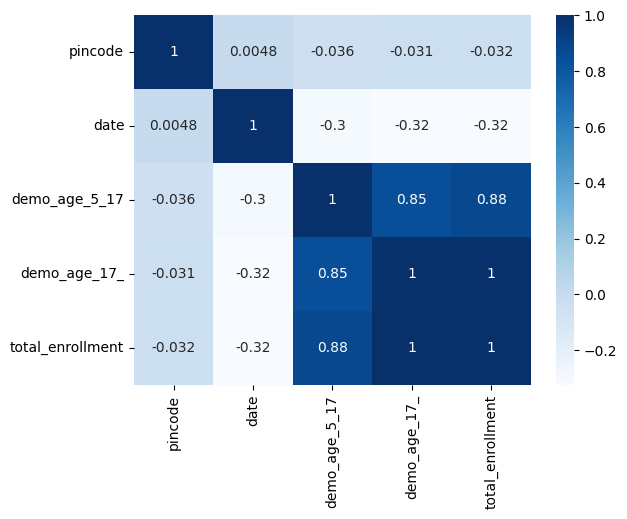

In [12]:
# Visualise correlations
df_intermediate = df.drop("state",axis = 1)
corr = df_intermediate.corr()
plt.figure()
sns.heatmap(corr,annot = True, cmap = "Blues")
plt.show()

In [13]:
# Calculate rolling mean and z-score of the enrollments per pincode
df["rolling_mean"] = df.groupby("pincode")["total_enrollment"].transform(lambda x: x.rolling(7,min_periods=1).mean())

df["z_score"] = ((df["total_enrollment"] - df["rolling_mean"]) /df.groupby("pincode")["total_enrollment"].transform("std"))

df.head(100)

,pincode,date,state,demo_age_5_17,demo_age_17_,total_enrollment,rolling_mean,z_score
0,110001,2025-03-01,Delhi,74,437,511,511.000000,0.000000
1,110001,2025-06-01,Delhi,44,321,365,438.000000,-1.088734
2,110001,2025-09-01,Delhi,2,13,15,297.000000,-4.205793
3,110001,2025-09-02,Delhi,0,6,6,224.250000,-3.255015
4,110001,2025-09-03,Delhi,3,11,14,182.200000,-2.508561
...,...,...,...,...,...,...,...,...
95,110002,2025-09-14,Delhi,0,4,4,17.428571,-0.151515
96,110002,2025-09-15,Delhi,1,18,19,19.571429,-0.006447
97,110002,2025-09-16,Delhi,5,22,27,20.857143,0.069310
98,110002,2025-09-17,Delhi,0,23,23,20.714286,0.025790


In [14]:
# Calculate no. of anomalous days per state
df["anomaly"] = df["z_score"].abs() > 3
df["anomaly"] = df["anomaly"].astype(int)
state_anomalies = df.groupby("state")["anomaly"].sum().sort_values()
state_anomalies

state
Lakshadweep                                    2
Ladakh                                         5
Dadra and Nagar Haveli and Daman and Diu       8
Andaman and Nicobar Islands                    9
Sikkim                                         9
Chandigarh                                    20
Puducherry                                    22
Nagaland                                      26
Manipur                                       29
Arunachal Pradesh                             31
Mizoram                                       37
Meghalaya                                     43
Goa                                           54
Tripura                                       64
Delhi                                        108
Uttarakhand                                  198
Jammu and Kashmir                            204
Himachal Pradesh                             219
Chhattisgarh                                 289
Jharkhand                                    312
Haryana       

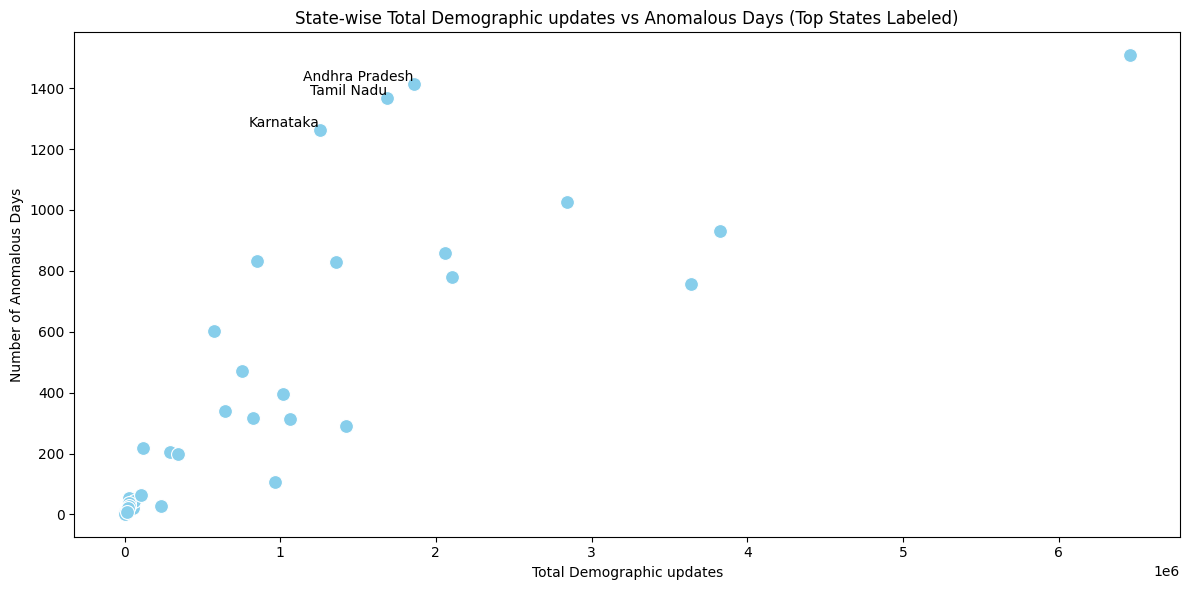

In [15]:
# Compute total enrollment & anomalies
df["anomaly_flag"] = (df["z_score"].abs() > 3).astype(int)

state_summary = df.groupby("state").agg(
    total_enrollment=("total_enrollment", "sum"),
    anomalies=("anomaly_flag", "sum")
).reset_index()

# Find the state with the highest total enrollment
highest_enrollment_state = state_summary.loc[state_summary["total_enrollment"].idxmax(), "state"]

# Select top anomalous states excluding the state with highest total enrollment
top_states = (
    state_summary[state_summary["state"] != highest_enrollment_state]
    .nlargest(3, "anomalies")
)

# Scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=state_summary,
    x="total_enrollment",
    y="anomalies",
    s=100,
    color="skyblue"
)

# Add labels only for selected top states
for i, row in top_states.iterrows():
    plt.text(
        row["total_enrollment"],
        row["anomalies"],
        row["state"],
        fontsize=10,
        ha="right",
        va="bottom"
    )

plt.title("State-wise Total Demographic updates vs Anomalous Days (Top States Labeled)")
plt.xlabel("Total Demographic updates")
plt.ylabel("Number of Anomalous Days")
plt.tight_layout()
plt.show()


In [16]:
# Remove redundant attributes(since age demographic of 5-17 and 17+ have high correlation, it is safe to drop them)
df.drop(["anomaly","demo_age_17_","demo_age_5_17","anomaly_flag","rolling_mean","z_score"], axis = 1, inplace=True)
df

,pincode,date,state,total_enrollment
0,110001,2025-03-01,Delhi,511
1,110001,2025-06-01,Delhi,365
2,110001,2025-09-01,Delhi,15
3,110001,2025-09-02,Delhi,6
4,110001,2025-09-03,Delhi,14
...,...,...,...,...
1298153,855456,2025-12-23,Bihar,2
1298154,855456,2025-12-24,Bihar,2
1298155,855456,2025-12-26,Bihar,2
1298156,855456,2025-12-28,Bihar,1


In [17]:
Q1 = df["total_enrollment"].quantile(0.25)
Q3 = df["total_enrollment"].quantile(0.75)
IQR = Q3 - Q1

df["spatial_outlier"] = (
    (df["total_enrollment"] < Q1 - 1.5 * IQR) |
    (df["total_enrollment"] > Q3 + 1.5 * IQR)
)

top_states = (
    df[df["spatial_outlier"]]
    .groupby("state")
    .size()
    .sort_values(ascending=False)
    .head(5)
)

print(top_states)

state
Uttar Pradesh    28272
Bihar            20261
Maharashtra      17380
West Bengal      12317
Chhattisgarh      5771
dtype: int64


In [18]:
state_demographics = {
    "Delhi": {"population": 22_300_000, "literacy_rate": 88.7},
    "Haryana": {"population": 30_900_000, "literacy_rate": 80.4},
    "Uttar Pradesh": {"population": 241_000_000, "literacy_rate": 73.0},
    "Punjab": {"population": 31_000_000, "literacy_rate": 83.7},
    "Chandigarh": {"population": 1_240_000, "literacy_rate": 86.4},
    "Himachal Pradesh": {"population": 7_540_000, "literacy_rate": 86.6},
    "Jammu and Kashmir": {"population": 13_700_000, "literacy_rate": 77.3},
    "Ladakh": {"population": 300_000, "literacy_rate": 77.0},
    "Uttarakhand": {"population": 10_100_000, "literacy_rate": 87.6},
    "Rajasthan": {"population": 81_900_000, "literacy_rate": 69.7},
    "Gujarat": {"population": 73_200_000, "literacy_rate": 82.4},
    "Dadra and Nagar Haveli and Daman and Diu": {"population": 670_000, "literacy_rate": 87.1},
    "Maharashtra": {"population": 128_000_000, "literacy_rate": 84.8},
    "Goa": {"population": 1_600_000, "literacy_rate": 87.4},
    "Madhya Pradesh": {"population": 87_600_000, "literacy_rate": 73.7},
    "Chhattisgarh": {"population": 30_800_000, "literacy_rate": 77.3},
    "Andhra Pradesh": {"population": 53_500_000, "literacy_rate": 72.6},
    "Telangana": {"population": 38_200_000, "literacy_rate": 72.8},
    "Tamil Nadu": {"population": 76_500_000, "literacy_rate": 82.9},
    "Puducherry": {"population": 1_650_000, "literacy_rate": 86.6},
    "Karnataka": {"population": 68_000_000, "literacy_rate": 77.2},
    "Kerala": {"population": 36_000_000, "literacy_rate": 96.2},
    "Lakshadweep": {"population": 74_000, "literacy_rate": 92.3},
    "West Bengal": {"population": 99_500_000, "literacy_rate": 80.5},
    "Sikkim": {"population": 700_000, "literacy_rate": 82.2},
    "Andaman and Nicobar Islands": {"population": 405_000, "literacy_rate": 87.0},
    "Odisha": {"population": 41_900_000, "literacy_rate": 77.3},
    "Assam": {"population": 36_300_000, "literacy_rate": 85.9},
    "Meghalaya": {"population": 3_400_000, "literacy_rate": 75.5},
    "Arunachal Pradesh": {"population": 1_600_000, "literacy_rate": 67.0},
    "Manipur": {"population": 3_100_000, "literacy_rate": 79.9},
    "Mizoram": {"population": 1_200_000, "literacy_rate": 91.3},
    "Nagaland": {"population": 2_300_000, "literacy_rate": 80.1},
    "Tripura": {"population": 4_100_000, "literacy_rate": 87.8},
    "Bihar": {"population": 128_500_000, "literacy_rate": 70.9},
    "Jharkhand": {"population": 40_000_000, "literacy_rate": 74.3}
}

df["population"] = df["state"].map(
    lambda s: state_demographics[s]["population"]
)
df["literacy_rate"] = df["state"].map(
    lambda s: state_demographics[s]["literacy_rate"]
)

df["normalized_enrollment"] = df["total_enrollment"] / df["population"]

df["normalized_enrollment_norm"] = (
    df["normalized_enrollment"] - df["normalized_enrollment"].min()
) / (
    df["normalized_enrollment"].max() - df["normalized_enrollment"].min()
)

state_enrollment = (
    df.groupby("state", as_index=False)
      .agg(
          normalized_enrollment_norm=("normalized_enrollment_norm", "mean")
      )
)


In [19]:
state_enrollment_without_normalized = (
    df.groupby("state", as_index=False)
      .agg(
          enrollment=("total_enrollment", "sum")
      ))

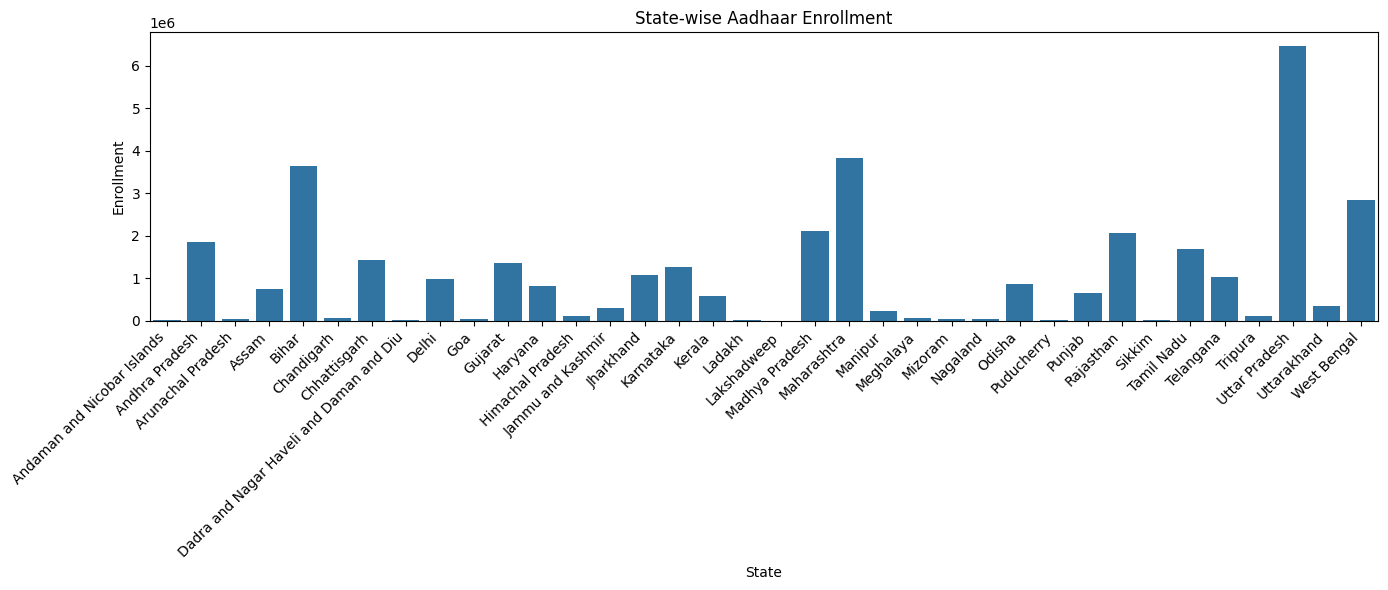

In [20]:
plt.figure(figsize=(14, 6))
sns.barplot(data=state_enrollment_without_normalized,x="state",y="enrollment")

plt.xticks(rotation=45, ha="right")
plt.title("State-wise Aadhaar Enrollment")
plt.xlabel("State")
plt.ylabel("Enrollment")
plt.tight_layout()
plt.show()

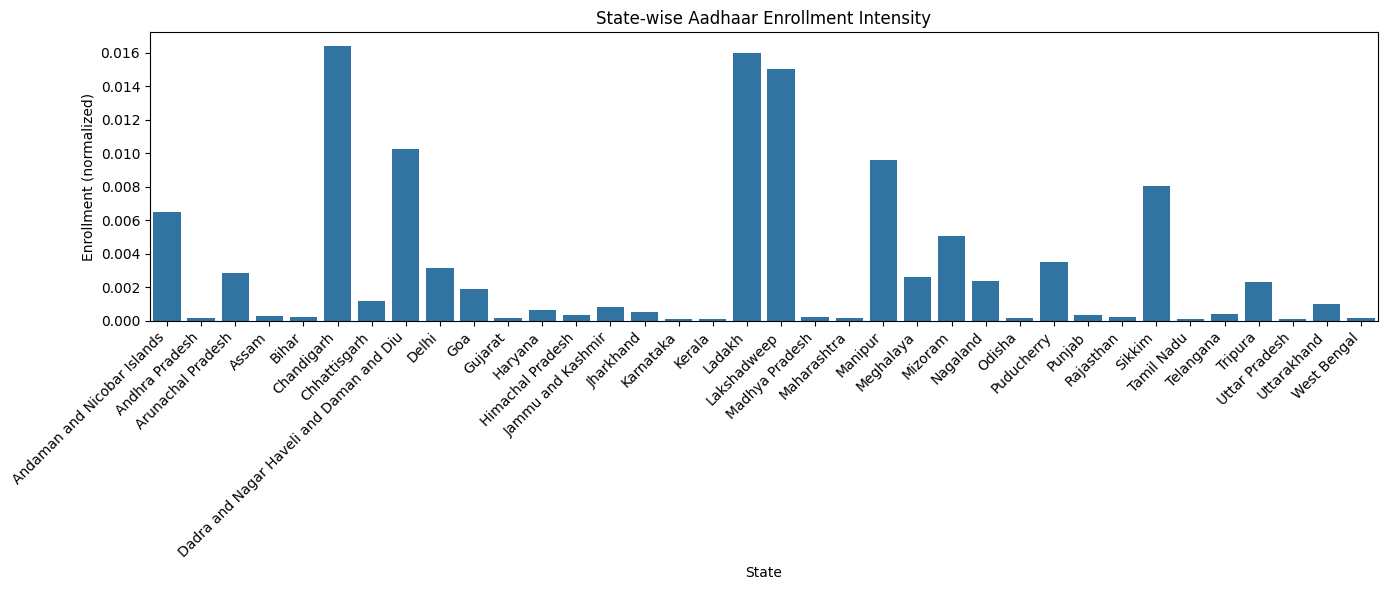

In [21]:
plt.figure(figsize=(14, 6))
sns.barplot(data=state_enrollment,x="state",y="normalized_enrollment_norm")

plt.xticks(rotation=45, ha="right")
plt.title("State-wise Aadhaar Enrollment Intensity")
plt.xlabel("State")
plt.ylabel("Enrollment (normalized)")
plt.tight_layout()
plt.show()

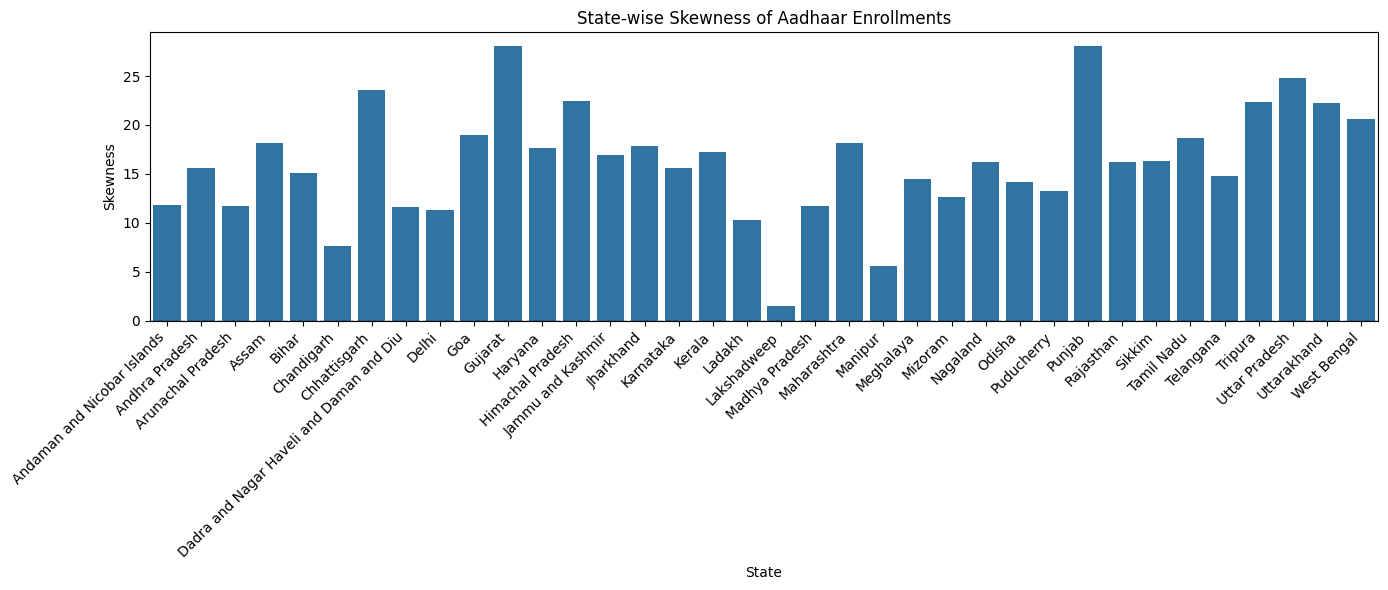

In [22]:
from scipy.stats import skew
state_skew = (
    df.groupby("state")["total_enrollment"]
      .apply(lambda x: skew(x, nan_policy="omit"))
      .reset_index(name="skewness")
)

plt.figure(figsize=(14,6))
sns.barplot(
    data=state_skew,
    x="state",
    y="skewness"
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.title("State-wise Skewness of Aadhaar Enrollments")
plt.ylabel("Skewness")
plt.xlabel("State")
plt.tight_layout()
plt.show()


In [23]:
df['week'] = df['date'].dt.isocalendar().week
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [24]:
monthly_skew = (
    df.groupby(["state", "month"])["total_enrollment"]
      .apply(lambda x: skew(x.dropna()))
      .reset_index(name="skewness")
)

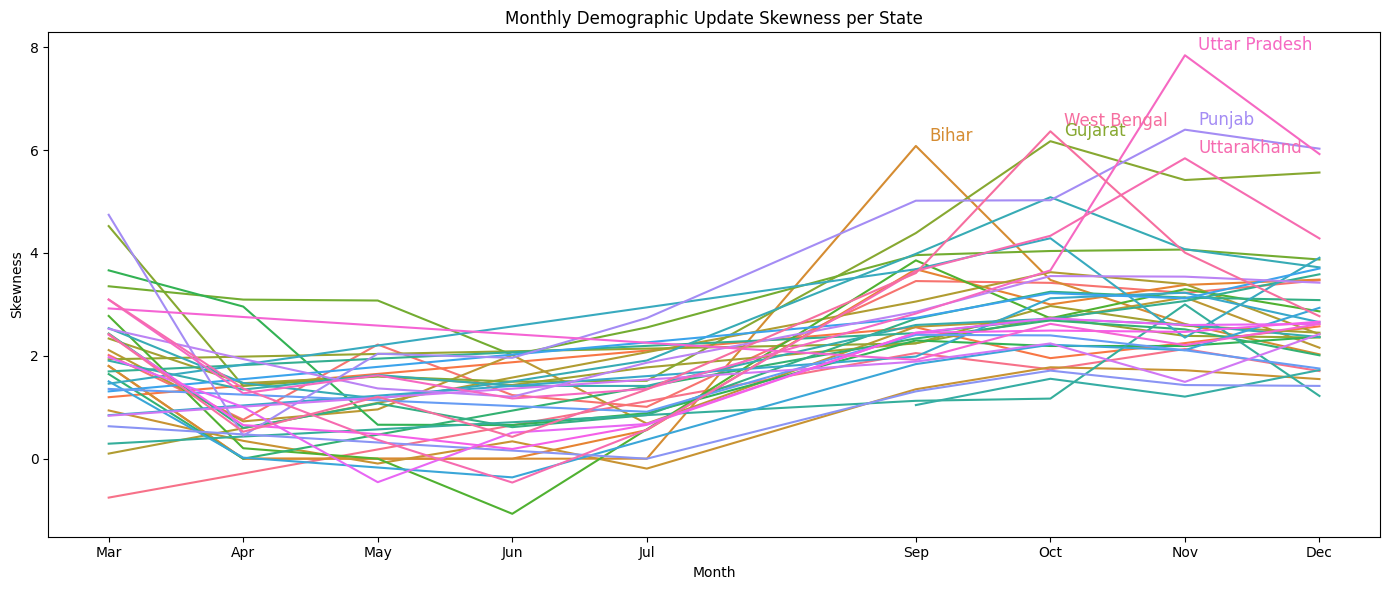

In [25]:
import calendar

monthly_skew_filtered = monthly_skew[monthly_skew["month"] >= 3]

peak_skew_per_state = monthly_skew_filtered.groupby("state")["skewness"].max()
top_states = peak_skew_per_state.sort_values(ascending=False).head(6).index

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_skew_filtered,
    x="month",
    y="skewness",
    hue="state",
    legend=False
)

# Label top 3 states at their peak skewness point
for state in top_states:
    peak_point = monthly_skew_filtered[monthly_skew_filtered["state"] == state].loc[
        monthly_skew_filtered[monthly_skew_filtered["state"] == state]["skewness"].idxmax()
    ]
    plt.text(
        x=peak_point["month"] + 0.1,
        y=peak_point["skewness"] + 0.1,
        s=state,
        fontsize=12,
        color=plt.gca().lines[list(monthly_skew_filtered["state"].unique()).index(state)].get_color()
    )

plt.title("Monthly Demographic Update Skewness per State")
plt.xlabel("Month")
plt.ylabel("Skewness")

plt.xticks(
    ticks=sorted(monthly_skew_filtered["month"].unique()),
    labels=[calendar.month_abbr[m] for m in sorted(monthly_skew_filtered["month"].unique())]
)

plt.tight_layout()
plt.show()